# Phase 6 — Uncertainty Estimation

## Uncertainty-Aware Material Selection using Machine Learning

### Objective

Quantify predictive uncertainty in bulk modulus predictions rather than
producing only point estimates.

The objective is to distinguish between predictions for which the model
shows relatively high agreement and predictions for which the model exhibits
greater uncertainty.

### Motivation

A material selection system should not treat two identical predicted property
values as equally reliable if their predictive uncertainties differ.

For example, two candidate materials may both have a predicted bulk modulus
of approximately 150 GPa, while one prediction may be considerably more
uncertain than the other.

Therefore, both predicted performance and predictive uncertainty will be
considered in subsequent material selection.

### Strategy

Random Forest provides an ensemble of decision trees. The distribution of
predictions produced by the individual trees will be used to investigate
model disagreement as an empirical uncertainty signal.

The Phase 5 Random Forest configuration will be used:

- `n_estimators = 300`
- `max_depth = 16`
- `min_samples_split = 2`
- `min_samples_leaf = 1`
- `max_features = 1.0`
- `random_state = 42`

The test set will remain untouched during uncertainty-method development.

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

df = pd.read_csv(
    "../data/processed/clean_materials_data.csv"
)

X = df.drop(columns=["K_VRH"])
y = df["K_VRH"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (944, 4)
Validation: (118, 4)
Test: (119, 4)


In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

numerical_features = [
    "nsites",
    "volume",
    "elastic_anisotropy"
]

categorical_features = [
    "space_group"
]

tree_preprocessor = ColumnTransformer([
    (
        "num",
        "passthrough",
        numerical_features
    ),
    (
        "cat",
        OneHotEncoder(
            handle_unknown="ignore"
        ),
        categorical_features
    )
])

rf_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    (
        "regressor",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=16,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=1.0,
            random_state=42,
            n_jobs=-1
        )
    )
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['nsites','volume','space_group','elastic_anisotropy']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated

In [3]:
X_val_processed = rf_model[
    "preprocessor"
].transform(X_val)

rf_regressor = rf_model[
    "regressor"
]

print("Processed validation shape:", X_val_processed.shape)
print("Number of trees:", len(rf_regressor.estimators_))

Processed validation shape: (118, 87)
Number of trees: 300


In [4]:
tree_predictions = np.array([
    tree.predict(X_val_processed)
    for tree in rf_regressor.estimators_
])

print("Tree predictions shape:", tree_predictions.shape)

Tree predictions shape: (300, 118)


In [5]:
val_mean_prediction = tree_predictions.mean(axis=0)
val_uncertainty = tree_predictions.std(axis=0)

print("Mean predictions shape:", val_mean_prediction.shape)
print("Uncertainty shape:", val_uncertainty.shape)

print(
    f"\nMean uncertainty: "
    f"{val_uncertainty.mean():.2f} GPa"
)

print(
    f"Median uncertainty: "
    f"{np.median(val_uncertainty):.2f} GPa"
)

print(
    f"Minimum uncertainty: "
    f"{val_uncertainty.min():.2f} GPa"
)

print(
    f"Maximum uncertainty: "
    f"{val_uncertainty.max():.2f} GPa"
)

Mean predictions shape: (118,)
Uncertainty shape: (118,)

Mean uncertainty: 40.83 GPa
Median uncertainty: 39.17 GPa
Minimum uncertainty: 12.73 GPa
Maximum uncertainty: 87.12 GPa


In [6]:
uncertainty_results = pd.DataFrame({
    "actual_K_VRH": y_val.to_numpy(),
    "predicted_K_VRH": val_mean_prediction,
    "uncertainty_std": val_uncertainty
})

uncertainty_results["absolute_error"] = np.abs(
    uncertainty_results["actual_K_VRH"]
    - uncertainty_results["predicted_K_VRH"]
)

uncertainty_results.head(10).round(2)

,actual_K_VRH,predicted_K_VRH,uncertainty_std,absolute_error
0,88.97,89.06,43.52,0.09
1,108.14,95.67,26.13,12.47
2,113.87,93.97,50.58,19.90
3,30.13,66.51,43.16,36.38
4,198.72,163.71,26.23,35.01
5,66.56,62.46,22.05,4.10
6,23.94,120.49,47.36,96.55
7,212.44,150.07,50.08,62.37
8,98.38,75.11,20.95,23.26
9,182.77,175.72,30.27,7.05


In [7]:
from scipy.stats import pearsonr, spearmanr

pearson_r, pearson_p = pearsonr(
    uncertainty_results["uncertainty_std"],
    uncertainty_results["absolute_error"]
)

spearman_r, spearman_p = spearmanr(
    uncertainty_results["uncertainty_std"],
    uncertainty_results["absolute_error"]
)

print("Uncertainty vs Absolute Error")
print("-----------------------------")

print(
    f"Pearson correlation:  "
    f"{pearson_r:.3f} "
    f"(p = {pearson_p:.4f})"
)

print(
    f"Spearman correlation: "
    f"{spearman_r:.3f} "
    f"(p = {spearman_p:.4f})"
)

Uncertainty vs Absolute Error
-----------------------------
Pearson correlation:  0.467 (p = 0.0000)
Spearman correlation: 0.372 (p = 0.0000)


In [8]:
uncertainty_results["uncertainty_group"] = pd.qcut(
    uncertainty_results["uncertainty_std"],
    q=4,
    labels=[
        "Q1 — Low",
        "Q2",
        "Q3",
        "Q4 — High"
    ]
)

uncertainty_group_summary = (
    uncertainty_results
    .groupby(
        "uncertainty_group",
        observed=True
    )
    .agg(
        n=("absolute_error", "size"),
        mean_uncertainty=("uncertainty_std", "mean"),
        mean_absolute_error=("absolute_error", "mean"),
        median_absolute_error=("absolute_error", "median")
    )
)

uncertainty_group_summary.round(2)

,n,mean_uncertainty,mean_absolute_error,median_absolute_error
uncertainty_group,,,,
Q1 — Low,30,23.76,22.35,12.92
Q2,29,34.86,35.83,22.85
Q3,29,44.03,29.08,25.08
Q4 — High,30,60.56,58.50,53.31


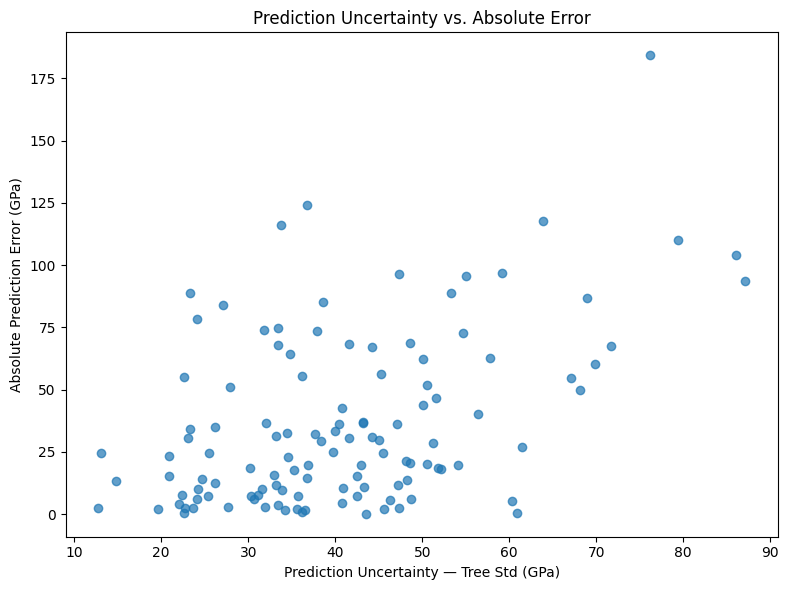

In [9]:
import matplotlib.pyplot as plt
from pathlib import Path

figures_dir = Path("../outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 6))

plt.scatter(
    uncertainty_results["uncertainty_std"],
    uncertainty_results["absolute_error"],
    alpha=0.7
)

plt.xlabel("Prediction Uncertainty — Tree Std (GPa)")
plt.ylabel("Absolute Prediction Error (GPa)")
plt.title("Prediction Uncertainty vs. Absolute Error")

plt.tight_layout()

plt.savefig(
    figures_dir / "uncertainty_vs_error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
coverage_levels = [
    1.00,
    0.90,
    0.80,
    0.70,
    0.60,
    0.50,
    0.40,
    0.30
]

sorted_results = uncertainty_results.sort_values(
    "uncertainty_std"
).reset_index(drop=True)

risk_coverage_results = []

for coverage in coverage_levels:

    n_keep = int(
        np.ceil(len(sorted_results) * coverage)
    )

    retained = sorted_results.iloc[:n_keep]

    retained_mae = retained[
        "absolute_error"
    ].mean()

    risk_coverage_results.append({
        "coverage": coverage,
        "n_materials": n_keep,
        "MAE": retained_mae
    })

risk_coverage_results = pd.DataFrame(
    risk_coverage_results
)

risk_coverage_results.round(2)

,coverage,n_materials,MAE
0,1.0,118,36.51
1,0.9,107,31.33
2,0.8,95,29.33
3,0.7,83,28.32
4,0.6,71,28.72
5,0.5,59,28.98
6,0.4,48,26.37
7,0.3,36,23.36


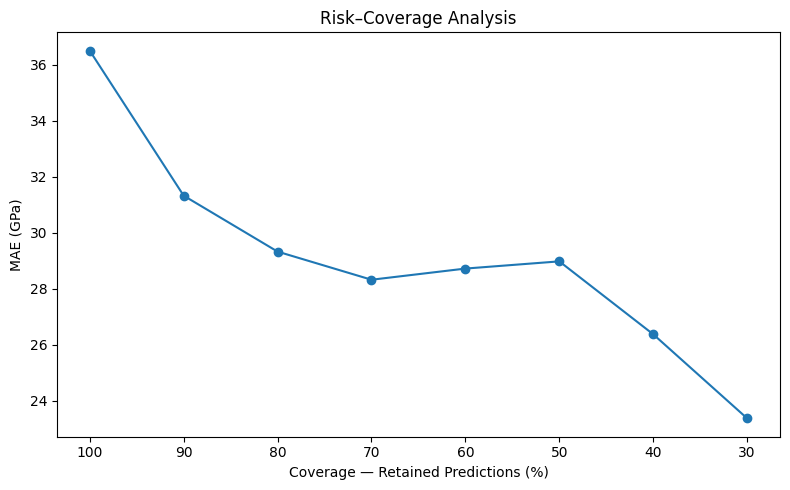

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    risk_coverage_results["coverage"] * 100,
    risk_coverage_results["MAE"],
    marker="o"
)

plt.xlabel("Coverage — Retained Predictions (%)")
plt.ylabel("MAE (GPa)")
plt.title("Risk–Coverage Analysis")

plt.gca().invert_xaxis()

plt.tight_layout()

plt.savefig(
    figures_dir / "risk_coverage_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Phase 6 Summary — Uncertainty Estimation

Predictive uncertainty was estimated using disagreement among the 300
individual decision trees of the selected Random Forest model.

For each validation material:

- The mean of the tree predictions was used as the predicted `K_VRH`.
- The standard deviation of the tree predictions was used as an empirical
  model-disagreement uncertainty signal.

This quantity should not be interpreted as a calibrated confidence interval
or as the expected prediction error. Instead, it represents disagreement
within the Random Forest ensemble.

### Uncertainty Distribution

Across the validation set:

- Mean uncertainty: 40.83 GPa
- Median uncertainty: 39.17 GPa
- Minimum uncertainty: 12.73 GPa
- Maximum uncertainty: 87.12 GPa

### Relationship Between Uncertainty and Prediction Error

Tree-based uncertainty showed a statistically significant positive
association with absolute prediction error:

- Pearson correlation: r = 0.467
- Spearman correlation: ρ = 0.372
- Both correlations were statistically significant (p < 0.0001)

Therefore, higher ensemble disagreement tends to be associated with larger
prediction errors, although the relationship is not deterministic.

### Uncertainty Groups

Dividing validation predictions into uncertainty quartiles revealed a clear
difference between the lowest- and highest-uncertainty groups:

- Q1 (low uncertainty): mean absolute error = 22.35 GPa
- Q4 (high uncertainty): mean absolute error = 58.50 GPa

The relationship was not perfectly monotonic across the intermediate
quartiles, but the highest-uncertainty group exhibited substantially larger
errors than the lowest-uncertainty group.

### Risk–Coverage Analysis

Predictions were ranked by uncertainty and progressively higher-uncertainty
predictions were excluded.

MAE decreased from:

- 36.51 GPa at 100% coverage
- 29.33 GPa at 80% coverage
- 28.32 GPa at 70% coverage
- 26.37 GPa at 40% coverage
- 23.36 GPa at 30% coverage

The risk–coverage relationship was not perfectly monotonic, but the overall
trend indicates that retaining lower-uncertainty predictions produces a more
reliable subset of predictions.

### Conclusion

Random Forest tree disagreement contains useful information about prediction
risk and can therefore be incorporated into an uncertainty-aware material
selection framework.

However, the uncertainty estimate is empirical and uncalibrated. It should
be treated as a relative risk indicator rather than a probabilistic
confidence interval.

The test set remains untouched.